# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.3'

<hr>

## Parameters

In [2]:
class Parameters:
    growth_model_choice = GrowthModelChoice.StaggeredDomanyKinzel
    # growth_model_choice = GrowthModelChoice.SimplifiedDomanyKinzel
    dim = Dimension.D1
    n_x: int = 1_000_000
    n_y: int = 1
    n_z: int = 1
    # p_1: float = 0.5055
    # p_1: float = 0.545
    # p_1: float = 0.538910
    p_1: float = 0.705485152
    p_2: float = 0
    n_iterations: int = 10_000
    sample_period: int  = 0
    initial_condition = InitialCondition.Randomized
    # initial_condition = InitialCondition.CentralSeed
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Unspecified
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_period to match n_iterations
if parameters.sample_period > parameters.n_iterations:
    parameters.sample_period = parameters.n_iterations

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [4]:
(n_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)


Growth model:  StaggeredDomanyKinzel
Dimension:     D1
Grid shape:    (1000000, 1, 1)
Prob. p_1:     0.705485152
Prob. p_2:     0
Iterations:    10000
Sample period: 0
Initial cond.: Randomized
Initial prob.: 0.99
Random seed:   1
Topology x:    Periodic
Topology y:    Unspecified
Topology z:    Unspecified
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Unspecified, Unspecified)
Axis BCs z:    (Unspecified, Unspecified)
BC values x:   (Occupied, Occupied)
BC values y:   (Empty, Empty)
BC values z:   (Empty, Empty)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16


Simulation run time (parallel): 9.256s


In [5]:
print(f"Total number of lattice time slices = {n_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [6]:
lattices: NDArray = np.array(raw_lattices, dtype=np.bool,).reshape(
    n_lattices, parameters.n_x,
).T
lattices.shape

(1000000, 0)

Tracking data, which for now is the vector pair (t; mean ρ):

In [7]:
pruned_tracking = []
for data in raw_tracking:
    if len(data)>0:
        pruned_tracking.append(data)

In [8]:
tracking: NDArray = np.array(pruned_tracking, dtype=np.float64,) 
tracking.shape

(2, 10001)

<hr>

## Visualization

### Prep

In [9]:
viz = Viz(dpi=125)
name: str

In [10]:
image_lattice_history = partial(
    viz.image_lattice_history,
    lattices=lattices, 
    p=parameters, 
    x=min(parameters.n_x, 300),
    t=min(n_lattices, 201),
    fig_size=(6, 4,),
)

### Evolution

lattice_p0p705485_s1_nx1000000


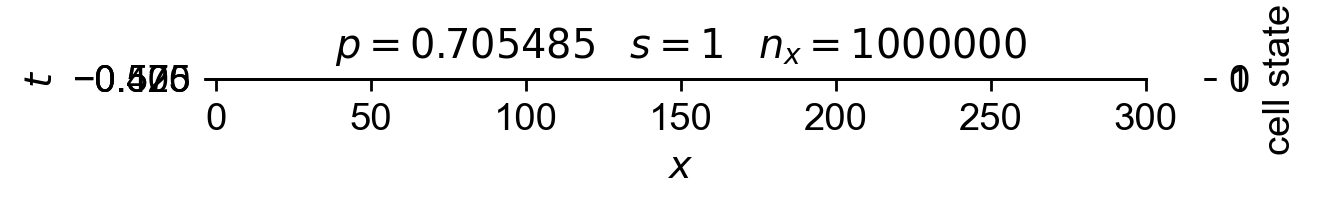

In [11]:
i_slice = 0
name = make_name(parameters, "lattice",)
print(name)
image_lattice_history(
    name=name, title=make_title(parameters), 
)
plt.show()

### Time decay

See Henkel et al (2008), tables 4.1 and 4.3: the decay rate of the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=1$ we should find $\delta \approx 0.1594646$ in 1d. 

Here I have heuristically tuned $p$ to
$$
    p = p_c? = \,\,0.538910
$$
which is close to the typically expected $\sim \!\!1/2$.

ρmean_p0p705485_s1_nx1000000


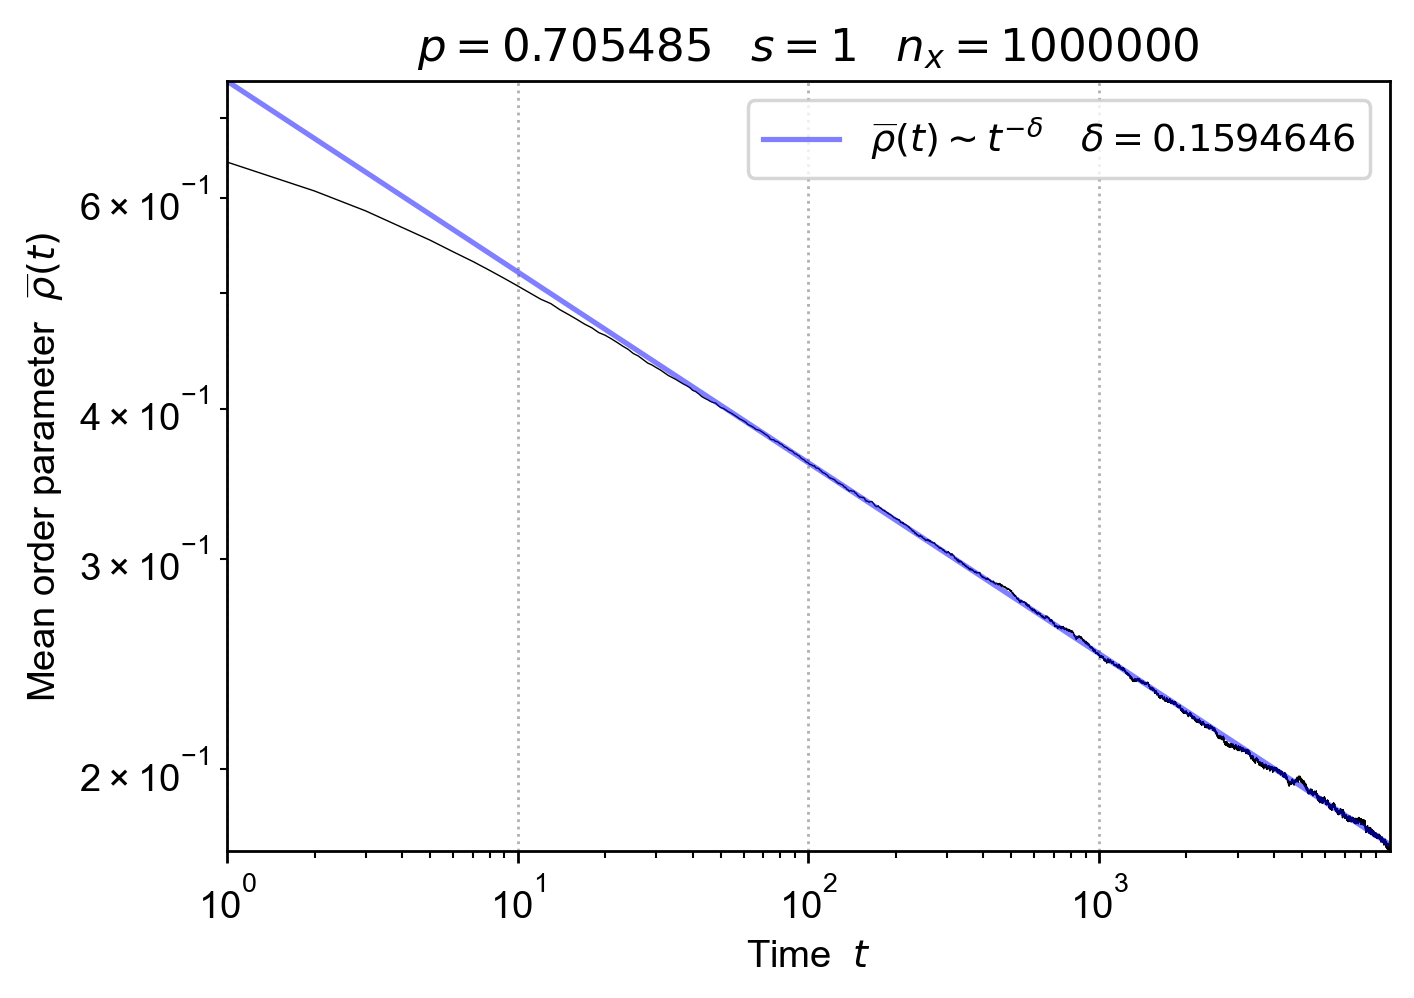

In [16]:
δ = 0.1594646
ρ_mean_ref = 0.665
ρ_mean_ref = 0.55
ρ_mean_ref = 0.752

name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_ρmean(
    name,
    make_title(parameters, None),
    tracking,
    δ, 
    ρ_mean_ref,
    fig_size=(6,4,),
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [13]:
i_offset: int = parameters.n_iterations//3
t: NDArray = tracking[0][i_offset:]
ρ_mean: NDArray = tracking[1][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))

print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

Estimated t-decay exponent:  δ = -0.157


<hr>

## Export

In [14]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp1d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp1d'